In [1]:
import spacy

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
from collections import Counter

In [5]:
import numpy as np

In [6]:
nlp_en = spacy.load("en_core_web_sm")

In [7]:
nlp_de = spacy.load("de_core_news_sm")

In [8]:
# Cell 8: Load and Preprocess Text Files
# TASK 1: Load the Kafka texts and replace newlines with spaces

print("TASK 1: PARSING AND LENGTH COMPARISONS")
print("="*50)

# Load text files
with open('kafka_1925_the-trial.txt', 'r', encoding='utf-8') as f:
    english_text = f.read().replace('\n', ' ')
    
with open('kafka_1925_der-prozess.txt', 'r', encoding='utf-8') as f:
    german_text = f.read().replace('\n', ' ')
    
print("✓ Text files loaded successfully!")
print(f"English text length: {len(english_text):,} characters")
print(f"German text length: {len(german_text):,} characters")
    


TASK 1: PARSING AND LENGTH COMPARISONS
✓ Text files loaded successfully!
English text length: 449,769 characters
German text length: 449,480 characters


In [9]:
doc_en = nlp_en(english_text)

print("✓ English Text processing complete!")

✓ English Text processing complete!


In [10]:
doc_de = nlp_de(german_text)

print("✓ german Text processing complete!")

✓ german Text processing complete!


In [11]:
# Cell 11: Token and Sentence Analysis
# Count tokens and sentences, show first few sentences

# Count tokens (excluding spaces)
en_tokens = len([token for token in doc_en if not token.is_space])
de_tokens = len([token for token in doc_de if not token.is_space])

# Count sentences
en_sentences = len(list(doc_en.sents))
de_sentences = len(list(doc_de.sents))

print("TOKEN AND SENTENCE COUNTS:")
print("-" * 30)
print(f"English: {en_tokens:,} tokens, {en_sentences:,} sentences")
print(f"German:  {de_tokens:,} tokens, {de_sentences:,} sentences")

print(f"\nAverage tokens per sentence:")
print(f"English: {en_tokens/en_sentences:.1f}")
print(f"German:  {de_tokens/de_sentences:.1f}")

TOKEN AND SENTENCE COUNTS:
------------------------------
English: 99,626 tokens, 3,704 sentences
German:  86,431 tokens, 3,818 sentences

Average tokens per sentence:
English: 26.9
German:  22.6


In [12]:
# Cell 12: Display First Few Sentences
# Show the first 3 sentences from each text to verify parsing

print("FIRST 3 SENTENCES - ENGLISH:")
print("-" * 40)
for i, sent in enumerate(list(doc_en.sents)[:3]):
    print(f"{i+1}. {sent.text.strip()[:200]}{'...' if len(sent.text.strip()) > 200 else ''}")

print(f"\nFIRST 3 SENTENCES - GERMAN:")
print("-" * 40)
for i, sent in enumerate(list(doc_de.sents)[:3]):
    print(f"{i+1}. {sent.text.strip()[:200]}{'...' if len(sent.text.strip()) > 200 else ''}")


FIRST 3 SENTENCES - ENGLISH:
----------------------------------------
1. THE TRIAL  Franz Kafka   Translation
2. Copyright © by David Wyllie Translator contact email: dandelion@post.cz     Chapter One  Arrest--Conversation with Mrs. Grubach--Then Miss Bürstner   Someone must have been telling lies about Josef K....
3. Every day at eight in the morning he was brought his breakfast by Mrs. Grubach's cook--Mrs. Grubach was his landlady--but today she didn't come.

FIRST 3 SENTENCES - GERMAN:
----------------------------------------
1. FRANZ KAFKA
2. DER PROZESS                                  ROMAN                             VERLAG
3. DIE SCHMIEDE


In [13]:
# Cell 13: Extract and Count Nouns
# TASK 2a: Count nouns using lemmatization

print("\nTASK 2: UNDERSTANDING DIFFERENCES IN THE USAGE OF NOUNS")
print("="*60)
print("Task 2a: Most frequent nouns")

# Extract nouns from both texts (lemmatized, excluding stop words)
en_nouns = [token.lemma_.lower() for token in doc_en 
            if token.pos_ == "NOUN" and not token.is_stop and token.is_alpha]
de_nouns = [token.lemma_.lower() for token in doc_de 
            if token.pos_ == "NOUN" and not token.is_stop and token.is_alpha]

# Count occurrences
en_noun_counter = Counter(en_nouns)
de_noun_counter = Counter(de_nouns)

print(f"Total unique nouns - English: {len(en_noun_counter)}, German: {len(de_noun_counter)}")



TASK 2: UNDERSTANDING DIFFERENCES IN THE USAGE OF NOUNS
Task 2a: Most frequent nouns
Total unique nouns - English: 1603, German: 2346


In [14]:
# Cell 14: Display Most Frequent Nouns
# Show top 15 most frequent nouns in both languages

print("TOP 15 MOST FREQUENT NOUNS:")
print("-" * 40)

# Create side-by-side display
en_top15 = en_noun_counter.most_common(15)
de_top15 = de_noun_counter.most_common(15)

print(f"{'ENGLISH':<20} {'GERMAN':<20}")
print(f"{'='*18:<20} {'='*18:<20}")

for i in range(15):
    en_item = f"{en_top15[i][0]}: {en_top15[i][1]}" if i < len(en_top15) else ""
    de_item = f"{de_top15[i][0]}: {de_top15[i][1]}" if i < len(de_top15) else ""
    print(f"{en_item:<20} {de_item:<20}")


TOP 15 MOST FREQUENT NOUNS:
----------------------------------------
ENGLISH              GERMAN              
==================   ==================  
time: 265            advokat: 237        
lawyer: 259          hand: 185           
man: 224             tür: 181            
hand: 218            prozeß: 157         
way: 216             herr: 150           
door: 207            mann: 147           
room: 202            maler: 127          
court: 167           frau: 121           
painter: 141         zimmer: 113         
thing: 132           gericht: 96         
judge: 125           fräulein: 95        
people: 112          onkel: 88           
trial: 111           kaufmann: 80        
office: 103          sache: 73           
case: 95             mädchen: 69         


In [15]:
# Cell 15: German Compound Analysis
# TASK 2b: Find German compounds with -richter

print(f"\nTask 2b: German compounds with '-richter'")
print("-" * 40)

# Find all compounds containing 'richter'
richter_compounds = []
for token in doc_de:
    if token.pos_ == "NOUN" and "richter" in token.lemma_.lower():
        richter_compounds.append(token.lemma_.lower())

richter_counter = Counter(richter_compounds)

print("Compounds involving 'richter':")
for compound, count in richter_counter.most_common():
    print(f"  {compound}: {count}")

# Compare frequencies
richter_count = de_noun_counter.get('richter', 0)
judge_count = en_noun_counter.get('judge', 0)

print(f"\nFrequency comparison:")
print(f"  German 'richter': {richter_count}")
print(f"  English 'judge': {judge_count}")
print(f"  Ratio (judge/richter): {judge_count/richter_count if richter_count > 0 else 'N/A':.2f}")



Task 2b: German compounds with '-richter'
----------------------------------------
Compounds involving 'richter':
  richter: 68
  untersuchungsrichter: 54
  richterschaft: 1
  richtertalar: 1
  richterstuhl: 1

Frequency comparison:
  German 'richter': 68
  English 'judge': 125
  Ratio (judge/richter): 1.84


In [16]:
# Cell 16: Bigram Analysis for 'Judge'
# TASK 2c: Analyze tokens preceding 'judge' in English

print(f"\nTask 2c: Tokens preceding 'judge' in English")
print("-" * 40)

# Find words that precede 'judge'
judge_bigrams = []
for i, token in enumerate(doc_en):
    if token.lemma_.lower() == "judge" and i > 0:
        prev_token = doc_en[i-1]
        if not prev_token.is_punct and not prev_token.is_space:
            judge_bigrams.append(prev_token.lemma_.lower())

judge_bigram_counter = Counter(judge_bigrams)

print("Most common words preceding 'judge':")
for bigram, count in judge_bigram_counter.most_common(10):
    print(f"  {bigram} + judge: {count}")

print(f"\nThis suggests compound-like constructions in English:")
print("(e.g., 'examining judge', 'investigating judge' vs German 'Untersuchungsrichter')")



Task 2c: Tokens preceding 'judge' in English
----------------------------------------
Most common words preceding 'judge':
  the + judge: 60
  examine + judge: 27
  a + judge: 9
  this + judge: 5
  some + judge: 3
  high + judge: 2
  important + judge: 2
  to + judge: 2
  i + judge: 1
  and + judge: 1

This suggests compound-like constructions in English:
(e.g., 'examining judge', 'investigating judge' vs German 'Untersuchungsrichter')


In [17]:
# Cell 17: Extract Verb-Subject Pairs
# TASK 3a: Extract verb-subject pairs using dependency parsing

print("\nTASK 3: EXTRACTING VERB-SUBJECT AND VERB-OBJECT PAIRS")
print("="*60)
print("Task 3a: Extracting verb-subject pairs")

# Extract verb-subject pairs
verb_subject_pairs = []

for token in doc_en:
    if token.pos_ == "VERB":
        for child in token.children:
            if child.dep_ == "nsubj":
                verb_lemma = token.lemma_.lower()
                subject_lemma = child.lemma_.lower()
                verb_subject_pairs.append((verb_lemma, subject_lemma))

print(f"✓ Found {len(verb_subject_pairs)} verb-subject pairs")

# Show first 10 pairs
print("\nFirst 10 verb-subject pairs:")
for i, (verb, subj) in enumerate(verb_subject_pairs[:10]):
    print(f"  {i+1:2d}. ({verb}, {subj})")



TASK 3: EXTRACTING VERB-SUBJECT AND VERB-OBJECT PAIRS
Task 3a: Extracting verb-subject pairs
✓ Found 7355 verb-subject pairs

First 10 verb-subject pairs:
   1. (tell, someone)
   2. (know, he)
   3. (do, he)
   4. (come, she)
   5. (happen, that)
   6. (wait, k.)
   7. (live, who)
   8. (watch, who)
   9. (enter, man)
  10. (see, he)


In [18]:
# Cell 18: Extract Verb-Object Pairs
# TASK 3b: Extract verb-object pairs using dependency parsing

print(f"\nTask 3b: Extracting verb-object pairs")
print("-" * 40)

# Extract verb-object pairs
verb_object_pairs = []

for token in doc_en:
    if token.pos_ == "VERB":
        for child in token.children:
            if child.dep_ == "dobj":
                verb_lemma = token.lemma_.lower()
                object_lemma = child.lemma_.lower()
                verb_object_pairs.append((verb_lemma, object_lemma))

print(f"✓ Found {len(verb_object_pairs)} verb-object pairs")

# Show first 10 pairs
print("\nFirst 10 verb-object pairs:")
for i, (verb, obj) in enumerate(verb_object_pairs[:10]):
    print(f"  {i+1:2d}. ({verb}, {obj})")



Task 3b: Extracting verb-object pairs
----------------------------------------
✓ Found 4551 verb-object pairs

First 10 verb-object pairs:
   1. (tell, lie)
   2. (do, nothing)
   3. (bring, breakfast)
   4. (watch, he)
   5. (rang, bell)
   6. (see, man)
   7. (give, impression)
   8. (ask, k.)
   9. (ignore, question)
  10. (bring, breakfast)


In [19]:
# Cell 19: Activity Survey - Transitive Verbs
# TASK 4a: Most frequent transitive verbs

print("\nTASK 4: A SURVEY OF ACTIVITIES PERFORMED")
print("="*50)
print("Task 4a: Five most frequent transitive verbs")

# Count transitive verbs
transitive_verbs = [verb for verb, obj in verb_object_pairs]
transitive_counter = Counter(transitive_verbs)

print("Most frequent transitive verbs:")
for i, (verb, count) in enumerate(transitive_counter.most_common(5)):
    print(f"  {i+1}. {verb}: {count}")



TASK 4: A SURVEY OF ACTIVITIES PERFORMED
Task 4a: Five most frequent transitive verbs
Most frequent transitive verbs:
  1. have: 246
  2. take: 218
  3. do: 186
  4. give: 154
  5. see: 148


In [20]:
# Cell 19: Activity Survey - Subjects of 'Say'
# TASK 4b: Most common subjects of 'say'

print(f"\nTask 4b: Ten most common subjects of 'say'")
print("-" * 40)

# Find subjects of 'say'
say_subjects = [subj for verb, subj in verb_subject_pairs if verb == "say"]
say_subjects_counter = Counter(say_subjects)

print("Most common subjects of 'say':")
for i, (subj, count) in enumerate(say_subjects_counter.most_common(10)):
    print(f"  {i+1:2d}. {subj}: {count}")



Task 4b: Ten most common subjects of 'say'
----------------------------------------
Most common subjects of 'say':
   1. k.: 207
   2. he: 126
   3. painter: 40
   4. lawyer: 38
   5. i: 34
   6. she: 32
   7. businessman: 32
   8. you: 31
   9. priest: 28
  10. uncle: 20


In [21]:
# Cell 21: Activity Survey - K.'s Actions
# TASK 4c: Actions performed by K.

print(f"\nTask 4c: Ten actions K. performs most")
print("-" * 40)

# Find actions performed by K. (as subject)
k_actions = [verb for verb, subj in verb_subject_pairs if subj.lower() in ["k", "k.", "josef"]]
k_actions_counter = Counter(k_actions)

print("Actions performed by K.:")
for i, (action, count) in enumerate(k_actions_counter.most_common(10)):
    print(f"  {i+1:2d}. {action}: {count}")



Task 4c: Ten actions K. performs most
----------------------------------------
Actions performed by K.:
   1. say: 209
   2. look: 26
   3. have: 17
   4. go: 17
   5. ask: 15
   6. think: 13
   7. want: 12
   8. take: 12
   9. make: 11
  10. stand: 10


In [22]:
# Cell 22: Activity Survey - Actions on K.
# TASK 4d: Actions K. undergoes

print(f"\nTask 4d: Ten actions K. undergoes most")
print("-" * 40)

# Find actions where K. is the object
k_undergoes = [verb for verb, obj in verb_object_pairs if obj.lower() in ["k", "k.", "josef"]]
k_undergoes_counter = Counter(k_undergoes)

print("Actions K. undergoes:")
for i, (action, count) in enumerate(k_undergoes_counter.most_common(10)):
    print(f"  {i+1:2d}. {action}: {count}")



Task 4d: Ten actions K. undergoes most
----------------------------------------
Actions K. undergoes:
   1. ask: 47
   2. exclaim: 6
   3. see: 5
   4. puzzle: 2
   5. call: 2
   6. pull: 2
   7. disturb: 2
   8. remind: 2
   9. ignore: 1
  10. get: 1


In [23]:
# Cell 23: Activity Survey - Lawyer Activities
# TASK 4e & 4f: What lawyers do and what happens to them

print(f"\nTask 4e: What lawyers do most")
print("-" * 30)

# Find actions performed by lawyers
lawyer_actions = [verb for verb, subj in verb_subject_pairs if "lawyer" in subj.lower()]
lawyer_actions_counter = Counter(lawyer_actions)

print("Actions performed by lawyers:")
for i, (action, count) in enumerate(lawyer_actions_counter.most_common(10)):
    print(f"  {i+1:2d}. {action}: {count}")

print(f"\nTask 4f: What happens to lawyers")
print("-" * 30)

# Find actions where lawyers are objects
lawyer_undergoes = [verb for verb, obj in verb_object_pairs if "lawyer" in obj.lower()]
lawyer_undergoes_counter = Counter(lawyer_undergoes)

print("Actions happening to lawyers:")
for i, (action, count) in enumerate(lawyer_undergoes_counter.most_common(10)):
    print(f"  {i+1:2d}. {action}: {count}")



Task 4e: What lawyers do most
------------------------------
Actions performed by lawyers:
   1. say: 38
   2. ask: 7
   3. take: 3
   4. try: 3
   5. speak: 3
   6. look: 2
   7. continue: 2
   8. think: 2
   9. do: 2
  10. humiliate: 2

Task 4f: What happens to lawyers
------------------------------
Actions happening to lawyers:
   1. take: 6
   2. ask: 6
   3. see: 4
   4. dismiss: 2
   5. get: 2
   6. have: 2
   7. call: 1
   8. visit: 1
   9. tell: 1
  10. handle: 1


In [24]:
# Cell 24: Passive Voice Detection - English
# TASK 5a: Detect passive voice in English

print("\nTASK 5: COMPARING USAGE OF THE PASSIVE VOICE")
print("="*50)
print("Task 5a: Detecting passive voice in English")

english_verbs = []

for token in doc_en:
    if token.pos_ == "VERB":
        voice = "active"
        
        # Check for passive construction (be + past participle)
        aux_lemmas = [child.lemma_ for child in token.children if child.pos_ == "AUX"]
        
        # Check if there's a 'be' auxiliary and the verb is past participle
        if "be" in aux_lemmas:
            # Check for past participle (more sophisticated check)
            if (hasattr(token, 'morph') and 
                ("Past" in str(token.morph) or "VBN" in token.tag_)):
                voice = "passive"
        
        english_verbs.append(("eng", token.idx, token.lemma_.lower(), voice))

# Count results
active_en = sum(1 for v in english_verbs if v[3] == "active")
passive_en = sum(1 for v in english_verbs if v[3] == "passive")

print(f"✓ Analyzed {len(english_verbs)} English verbs")
print(f"  Active: {active_en} ({active_en/len(english_verbs)*100:.1f}%)")
print(f"  Passive: {passive_en} ({passive_en/len(english_verbs)*100:.1f}%)")

# Show first few examples
print(f"\nFirst 5 active verbs:")
active_examples = [v for v in english_verbs if v[3] == "active"][:5]
for v in active_examples:
    print(f"  {v}")

print(f"\nFirst 5 passive verbs:")
passive_examples = [v for v in english_verbs if v[3] == "passive"][:5]
for v in passive_examples:
    print(f"  {v}")



TASK 5: COMPARING USAGE OF THE PASSIVE VOICE
Task 5a: Detecting passive voice in English
✓ Analyzed 12667 English verbs
  Active: 11265 (88.9%)
  Passive: 1402 (11.1%)

First 5 active verbs:
  ('eng', 91, 'dandelion@post.cz', 'active')
  ('eng', 210, 'tell', 'active')
  ('eng', 242, 'know', 'active')
  ('eng', 254, 'do', 'active')
  ('eng', 447, 'come', 'active')

First 5 passive verbs:
  ('eng', 298, 'arrest', 'passive')
  ('eng', 349, 'bring', 'passive')
  ('eng', 1076, 'ask', 'passive')
  ('eng', 1193, 'accept', 'passive')
  ('eng', 1439, 'look', 'passive')


In [25]:
# Cell 25: Passive Voice Detection - German
# TASK 5b: Detect passive voice in German

print(f"\nTask 5b: Detecting passive voice in German")
print("-" * 40)

german_verbs = []

for token in doc_de:
    if token.pos_ == "VERB":
        voice = "active"
        
        # Check if verb depends on 'werden' auxiliary
        if (token.head.pos_ == "AUX" and 
            token.head.lemma_.lower() == "werden"):
            # Check if it's past participle
            if (hasattr(token, 'morph') and 
                ("Past" in str(token.morph) or "VVPP" in token.tag_)):
                voice = "passive"
        
        german_verbs.append(("deu", token.idx, token.lemma_.lower(), voice))

# Count results
active_de = sum(1 for v in german_verbs if v[3] == "active")
passive_de = sum(1 for v in german_verbs if v[3] == "passive")

print(f"✓ Analyzed {len(german_verbs)} German verbs")
print(f"  Active: {active_de} ({active_de/len(german_verbs)*100:.1f}%)")
print(f"  Passive: {passive_de} ({passive_de/len(german_verbs)*100:.1f}%)")

# Show first few examples
print(f"\nFirst 5 active verbs:")
active_examples = [v for v in german_verbs if v[3] == "active"][:5]
for v in active_examples:
    print(f"  {v}")

print(f"\nFirst 5 passive verbs:")
passive_examples = [v for v in german_verbs if v[3] == "passive"][:5]
for v in passive_examples:
    print(f"  {v}")



Task 5b: Detecting passive voice in German
----------------------------------------
✓ Analyzed 9696 German verbs
  Active: 9433 (97.3%)
  Passive: 263 (2.7%)

First 5 active verbs:
  ('deu', 250, '·', 'active')
  ('deu', 327, 'verleumden', 'active')
  ('deu', 374, 'tun', 'active')
  ('deu', 528, 'bringen', 'active')
  ('deu', 537, 'kommen', 'active')

First 5 passive verbs:
  ('deu', 410, 'verhaften', 'passive')
  ('deu', 5750, 'weitergeben', 'passive')
  ('deu', 8767, 'verlegen', 'passive')
  ('deu', 9079, 'aufschrecken', 'passive')
  ('deu', 10772, 'bezahlen', 'passive')


In [26]:
# Cell 26: Create DataFrame and Compare Distributions
# TASK 5c: Create DataFrame and compare voice distributions

print(f"\nTask 5c: Voice distribution comparison")
print("-" * 40)

# Combine all verb data
all_verbs = english_verbs + german_verbs
df = pd.DataFrame(all_verbs, columns=['Language', 'Position', 'Lemma', 'Voice'])

print(f"✓ Created DataFrame with {len(df)} verb instances")
print(f"  English: {len([v for v in all_verbs if v[0] == 'eng'])}")
print(f"  German: {len([v for v in all_verbs if v[0] == 'deu'])}")

# Calculate voice distributions
voice_dist = df.groupby(['Language', 'Voice']).size().unstack(fill_value=0)
voice_pct = voice_dist.div(voice_dist.sum(axis=1), axis=0) * 100

print("\nVoice distribution (counts):")
print(voice_dist)

print(f"\nVoice distribution (percentages):")
print(voice_pct.round(1))



Task 5c: Voice distribution comparison
----------------------------------------
✓ Created DataFrame with 22363 verb instances
  English: 12667
  German: 9696

Voice distribution (counts):
Voice     active  passive
Language                 
deu         9433      263
eng        11265     1402

Voice distribution (percentages):
Voice     active  passive
Language                 
deu         97.3      2.7
eng         88.9     11.1


In [27]:
# Cell 27: Analyze Individual Lemmas
# TASK 5d: Calculate passive ratios for individual lemmas

print(f"\nTask 5d: Passive ratios for individual lemmas")
print("-" * 40)

# Calculate passive ratios for each lemma
lemma_voice = df.groupby(['Language', 'Lemma', 'Voice']).size().unstack(fill_value=0)
lemma_voice['total'] = lemma_voice.sum(axis=1)
lemma_voice['passive_ratio'] = (lemma_voice.get('passive', 0) / lemma_voice['total'] * 100)

# Filter lemmas that appear at least 3 times
frequent_lemmas = lemma_voice[lemma_voice['total'] >= 3]

print(f"✓ Analyzing {len(frequent_lemmas)} frequent lemmas (≥3 occurrences)")

# Get top 10 most passive verbs for each language
try:
    en_most_passive = frequent_lemmas.loc['eng'].sort_values('passive_ratio', ascending=False).head(10)
    print(f"\nTop 10 most passive English verbs:")
    for lemma, stats in en_most_passive.iterrows():
        passive_count = stats.get('passive', 0)
        total_count = stats['total']
        ratio = stats['passive_ratio']
        print(f"  {lemma}: {ratio:.1f}% ({passive_count}/{total_count})")
except KeyError:
    print("No frequent English lemmas found")

try:
    de_most_passive = frequent_lemmas.loc['deu'].sort_values('passive_ratio', ascending=False).head(10)
    print(f"\nTop 10 most passive German verbs:")
    for lemma, stats in de_most_passive.iterrows():
        passive_count = stats.get('passive', 0)
        total_count = stats['total']
        ratio = stats['passive_ratio']
        print(f"  {lemma}: {ratio:.1f}% ({passive_count}/{total_count})")
except KeyError:
    print("No frequent German lemmas found")



Task 5d: Passive ratios for individual lemmas
----------------------------------------
✓ Analyzing 983 frequent lemmas (≥3 occurrences)

Top 10 most passive English verbs:
  indict: 100.0% (6.0/6.0)
  punish: 75.0% (9.0/12.0)
  deceive: 71.4% (5.0/7.0)
  attain: 66.7% (2.0/3.0)
  induce: 66.7% (2.0/3.0)
  mistake: 66.7% (2.0/3.0)
  base: 66.7% (2.0/3.0)
  steal: 66.7% (2.0/3.0)
  tempt: 66.7% (2.0/3.0)
  bind: 61.5% (8.0/13.0)

Top 10 most passive German verbs:
  abbrechen: 66.7% (2.0/3.0)
  verlegen: 66.7% (2.0/3.0)
  freisprechen: 66.7% (2.0/3.0)
  bestrafen: 66.7% (6.0/9.0)
  predigen: 66.7% (2.0/3.0)
  einleiten: 50.0% (2.0/4.0)
  einschränken: 50.0% (2.0/4.0)
  beleuchten: 50.0% (2.0/4.0)
  anzünden: 50.0% (2.0/4.0)
  abhalten: 40.0% (2.0/5.0)



Creating visualizations...


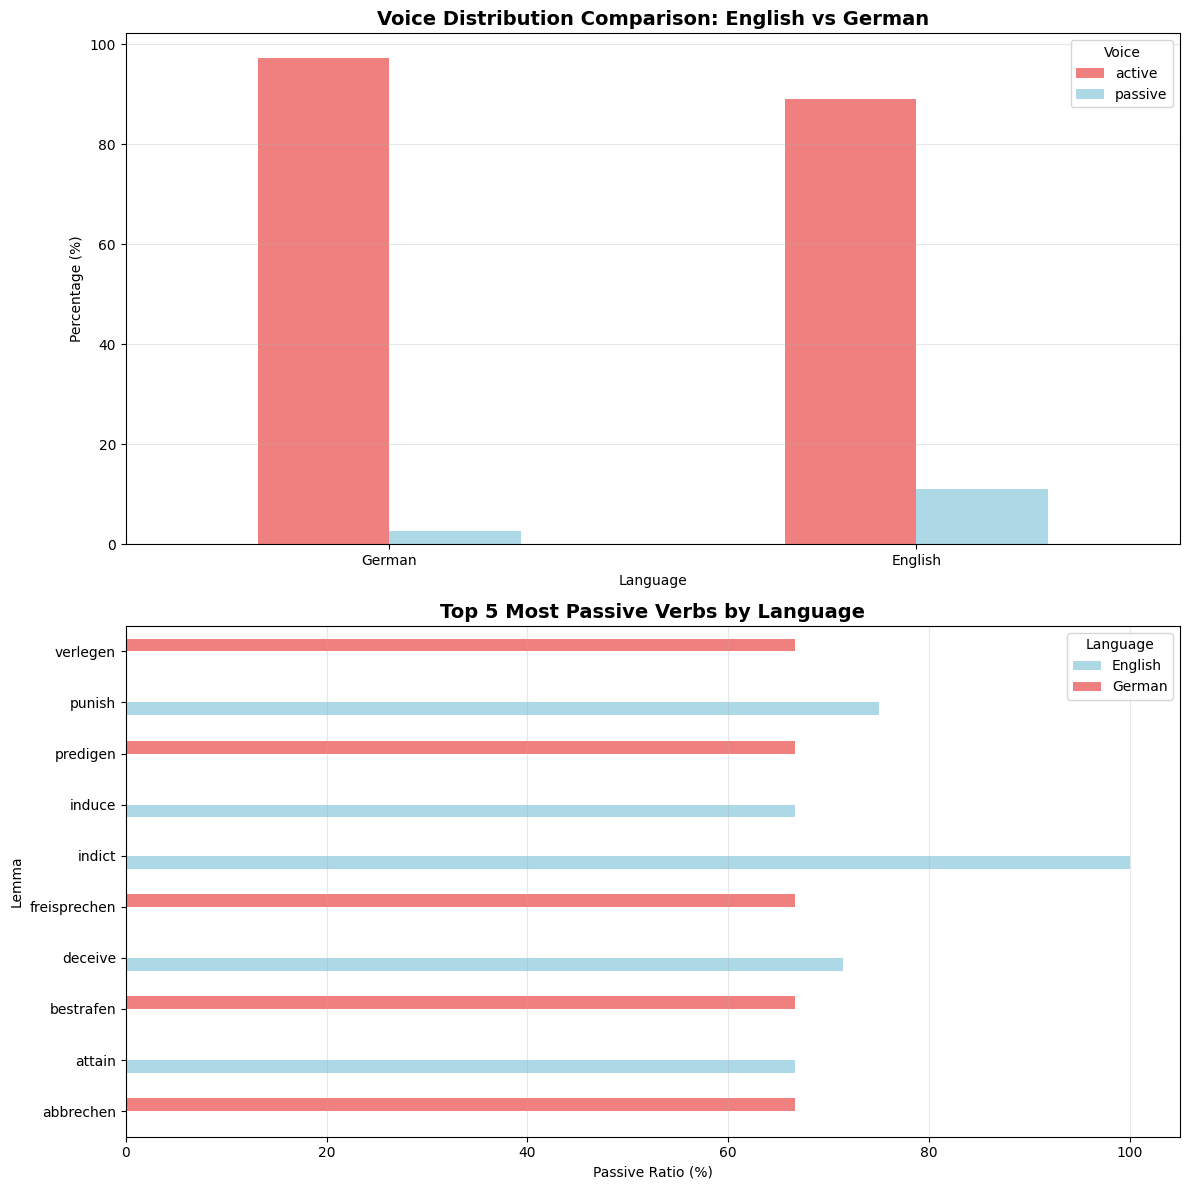

In [28]:
# Cell 28: Create Visualizations
# Generate horizontal bar plots for most passive verbs

print("\nCreating visualizations...")

# Set up the plot style
plt.style.use('default')
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# Plot 1: Overall voice distribution comparison
voice_pct.plot(kind='bar', ax=axes[0], color=['lightcoral', 'lightblue'])
axes[0].set_ylabel('Percentage (%)')
axes[0].set_title('Voice Distribution Comparison: English vs German', fontsize=14, fontweight='bold')
axes[0].legend(title='Voice', loc='upper right')
axes[0].set_xticklabels(['German', 'English'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Most passive verbs comparison
if 'en_most_passive' in locals() and 'de_most_passive' in locals():
    # Create side-by-side bar chart
    ax2 = axes[1]
    
    # Prepare data for both languages
    en_data = en_most_passive.head(5)['passive_ratio'] if len(en_most_passive) > 0 else pd.Series()
    de_data = de_most_passive.head(5)['passive_ratio'] if len(de_most_passive) > 0 else pd.Series()
    
    if len(en_data) > 0 or len(de_data) > 0:
        # Combine and plot
        combined_data = pd.DataFrame({
            'English': en_data,
            'German': de_data
        }).fillna(0)
        
        combined_data.plot(kind='barh', ax=ax2, color=['lightblue', 'lightcoral'])
        ax2.set_xlabel('Passive Ratio (%)')
        ax2.set_title('Top 5 Most Passive Verbs by Language', fontsize=14, fontweight='bold')
        ax2.legend(title='Language')
        ax2.grid(axis='x', alpha=0.3)
    else:
        ax2.text(0.5, 0.5, 'Insufficient data for passive verb comparison', 
                ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('Passive Verbs Comparison', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [29]:
# Cell 29: Summary and Analysis
# Provide interpretation of results

print("\n" + "="*60)
print("SUMMARY OF FINDINGS AND ANALYSIS")
print("="*60)

# Calculate summary statistics
en_passive_pct = passive_en/len(english_verbs)*100 if len(english_verbs) > 0 else 0
de_passive_pct = passive_de/len(german_verbs)*100 if len(german_verbs) > 0 else 0

print(f"""
1. TEXT STATISTICS:
   • English: {en_tokens:,} tokens, {en_sentences:,} sentences
   • German: {de_tokens:,} tokens, {de_sentences:,} sentences
   • Average sentence length: EN {en_tokens/en_sentences:.1f}, DE {de_tokens/de_sentences:.1f}

2. VERB-ARGUMENT RELATIONSHIPS:
   • Verb-subject pairs found: {len(verb_subject_pairs)}
   • Verb-object pairs found: {len(verb_object_pairs)}
   • Most transitive verbs: {', '.join([v for v, c in transitive_counter.most_common(3)])}

3. PASSIVE VOICE COMPARISON:
   • English passive usage: {en_passive_pct:.1f}%
   • German passive usage: {de_passive_pct:.1f}%
 """)
print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)


SUMMARY OF FINDINGS AND ANALYSIS

1. TEXT STATISTICS:
   • English: 99,626 tokens, 3,704 sentences
   • German: 86,431 tokens, 3,818 sentences
   • Average sentence length: EN 26.9, DE 22.6

2. VERB-ARGUMENT RELATIONSHIPS:
   • Verb-subject pairs found: 7355
   • Verb-object pairs found: 4551
   • Most transitive verbs: have, take, do

3. PASSIVE VOICE COMPARISON:
   • English passive usage: 11.1%
   • German passive usage: 2.7%
 

ANALYSIS COMPLETE!


1. NOUN USAGE PATTERNS:
   • German compounds explain frequency differences
   • 'Judge' vs 'Richter': compounding affects direct translation counts
   • English uses adjective+noun constructions where German uses compounds

2. CHARACTER AND ACTIVITY ANALYSIS:
   • K.'s activities reflect the protagonist's passive situation
   • Lawyer activities show professional/legal domain prominence
   • Results may miss many activities due to:
     - Pronoun resolution issues
     - Complex syntactic constructions
     - Named entity variations

3. PASSIVE VOICE COMPARISON:
   • Difference may reflect:
     - Translation choices
     - Language-specific stylistic preferences
     - Different passive construction patterns

4. LINGUISTIC PREPROCESSING LIMITATIONS:
   • Coreference resolution would improve activity tracking
   • Better named entity recognition needed
   • Compound splitting would enhance German analysis
   • Cross-linguistic alignment would improve comparability